In [1]:
import sys
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
import numpy as np
import torch
import trimesh
from PIL import Image
import matplotlib.pyplot as plt

sys.path.insert(0, '/home/vlad/diploma/Machine_learning/models/TripoSR')

import pythreejs as p3d
from IPython.display import display

from tsr.system import TSR
from tsr.utils import scale_tensor

from rembg import remove, new_session

In [2]:
def fixed_extract_mesh(self, scene_codes, has_vertex_color=True, resolution: int = 256, threshold: float = 25.0):
    self.set_marching_cubes_resolution(resolution)
    meshes = []
    
    for scene_code in scene_codes:
        # Определяем устройство
        device = scene_code.device if isinstance(scene_code, torch.Tensor) else scene_code[0].device
        
        with torch.no_grad():
            density = self.renderer.query_triplane(
                self.decoder,
                scale_tensor(
                    self.isosurface_helper.grid_vertices.to(device),
                    self.isosurface_helper.points_range,
                    (-self.renderer.cfg.radius, self.renderer.cfg.radius),
                ),
                scene_code,
            )["density_act"]
        
        v_pos, t_pos_idx = self.isosurface_helper(-(density - threshold))
        v_pos = scale_tensor(
            v_pos,
            self.isosurface_helper.points_range,
            (-self.renderer.cfg.radius, self.renderer.cfg.radius),
        )
        
        # 🔧 КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: Переносим v_pos на GPU
        v_pos = v_pos.to(device)
        
        color = None
        if has_vertex_color:
            with torch.no_grad():
                color = self.renderer.query_triplane(
                    self.decoder, 
                    v_pos.to(device),  # ← Гарантируем устройство
                    scene_code,
                )["color"]
        
        mesh = trimesh.Trimesh(
            vertices=v_pos.cpu().numpy(),
            faces=t_pos_idx.cpu().numpy(),
            vertex_colors=color.cpu().numpy() if has_vertex_color else None,
        )
        meshes.append(mesh)
    
    return meshes

# 🔧 ПРИМЕНЯЕМ ПАТЧ К КЛАССУ!
TSR.extract_mesh = fixed_extract_mesh
print("✓ Патч применён к классу TSR!\n")

✓ Патч применён к классу TSR!



In [3]:
if torch.cuda.is_available():
    device = "cuda:0"
    print(f"✓ CUDA: Available")
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("⚠ CUDA: Not available, using CPU")

✓ CUDA: Available
✓ GPU: NVIDIA GeForce RTX 4060


In [4]:
model = TSR.from_pretrained(
    "stabilityai/TripoSR",
    config_name="config.yaml",
    weight_name="model.ckpt",
)
model.renderer.set_chunk_size(8192)
model = model.to(device)
model.eval()
print("✓ Модель загружена!\n")

✓ Модель загружена!



In [5]:
rembg_session = new_session()

In [6]:
def resize_foreground(image, ratio=0.9):
    """Обрезает изображение, оставляя объект в центре"""
    image = np.array(image)
    alpha = image[:, :, 3] if image.shape[2] == 4 else np.ones(image.shape[:2]) * 255
    mask = alpha > 128
    
    if not mask.any():
        return Image.fromarray(image[:, :, :3])
    
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    
    h, w = image.shape[:2]
    size = max(x1 - x0, y1 - y0)
    x0 = max(0, int((x0 + x1) / 2 - size / 2 / ratio))
    y0 = max(0, int((y0 + y1) / 2 - size / 2 / ratio))
    size = int(size / ratio)
    x1 = min(w, x0 + size)
    y1 = min(h, y0 + size)
    
    cropped = image[y0:y1, x0:x1]
    new_size = max(cropped.shape[0], cropped.shape[1])
    padded = np.ones((new_size, new_size, 4), dtype=np.uint8) * 255
    padded[:cropped.shape[0], :cropped.shape[1]] = cropped
    
    return Image.fromarray(padded)

def preprocess_image(input_image, do_remove_background=True, foreground_ratio=0.9):
    """Полный препроцессинг изображения"""
    if do_remove_background:
        image = remove(input_image, session=rembg_session)
        image = resize_foreground(image, foreground_ratio)
        
        # Заполняем фон белым
        image = np.array(image).astype(np.float32) / 255.0
        image = image[:, :, :3] * image[:, :, 3:4] + (1 - image[:, :, 3:4]) * 0.5
        image = Image.fromarray((image * 255.0).astype(np.uint8))
    else:
        image = input_image.convert("RGB")
    
    return image

def to_gradio_orientation(mesh):
    """Поворачивает меш в правильную ориентацию"""
    transform = trimesh.transformations.rotation_matrix(np.radians(-90), [1, 0, 0])
    mesh.apply_transform(transform)
    return mesh

In [7]:
def visualize_mesh(mesh):
    """Визуализирует меш с vertex colors"""
    vertices = np.array(mesh.vertices, dtype=np.float32)
    faces = np.array(mesh.faces.flatten(), dtype=np.uint32)
    
    colors = None
    if hasattr(mesh.visual, 'vertex_colors') and mesh.visual.vertex_colors is not None:
        vc = mesh.visual.vertex_colors
        colors = np.array(vc[:, :3] / 255.0, dtype=np.float32)
        print(f"✓ Vertex colors: {len(colors)} вершин")
    
    geometry_kwargs = {
        'attributes': {
            'position': p3d.BufferAttribute(vertices, normalized=False),
            'index': p3d.BufferAttribute(faces, normalized=False),
        }
    }
    
    if colors is not None:
        geometry_kwargs['attributes']['color'] = p3d.BufferAttribute(colors, normalized=False)
    
    geometry = p3d.BufferGeometry(**geometry_kwargs)
    
    material = p3d.MeshStandardMaterial(
        vertexColors='VertexColors' if colors is not None else 'NoColors',
        metalness=0.1,
        roughness=0.5,
        side='DoubleSide'
    )
    
    mesh_widget = p3d.Mesh(geometry=geometry, material=material)
    
    bbox = mesh.bounds
    center = mesh.centroid
    size = np.linalg.norm(bbox[1] - bbox[0])
    
    camera = p3d.PerspectiveCamera(
        position=[float(center[0]), float(center[1]), float(center[2] + size * 1.5)],
        aspect=1,
        fov=50,
    )
    
    scene = p3d.Scene(
        children=[
            mesh_widget, 
            camera, 
            p3d.AmbientLight(intensity=0.6),
            p3d.DirectionalLight(position=[1, 1, 1], intensity=0.8)
        ]
    )
    
    controller = p3d.OrbitControls(controlling=camera)
    renderer = p3d.Renderer(
        camera=camera, 
        scene=scene, 
        controls=[controller], 
        width=700, 
        height=500,
        antialias=True
    )
    return renderer

In [8]:
def generate_3d(input_image, mc_resolution=256, threshold=25.0, device="cuda:0"):
    """Генерирует 3D модель из изображения"""
    with torch.no_grad():
        scene_codes = model([input_image], device=device)
        
        meshes = model.extract_mesh(
            scene_codes,
            resolution=mc_resolution,
            has_vertex_color=True,
            threshold=threshold
        )
    
    mesh = to_gradio_orientation(meshes[0])
    return mesh


Загрузка изображения: /home/vlad/diploma/Machine_learning/src/test_image.jpg


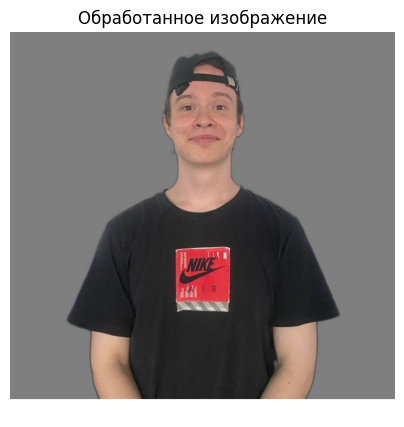

In [9]:
image_path = "/home/vlad/diploma/Machine_learning/src/test_image.jpg"

# Загрузка и препроцессинг
print(f"\nЗагрузка изображения: {image_path}")
input_image = Image.open(image_path).convert("RGBA")
processed_image = preprocess_image(input_image, do_remove_background=True, foreground_ratio=0.9)

plt.figure(figsize=(5, 5))
plt.imshow(processed_image)
plt.axis('off')
plt.title("Обработанное изображение")
plt.show()

In [10]:
torch.cuda.empty_cache()
torch.cuda.synchronize()

print("\nГенерация 3D модели...")
mesh = generate_3d(processed_image, mc_resolution=400, threshold=20.0, device=device)

os.makedirs("output_3d", exist_ok=True)
mesh.export("output_3d/tripoSR_final.glb")
print(f"\n✓ Вершин: {len(mesh.vertices)}")
print(f"✓ Размер: {os.path.getsize('output_3d/tripoSR_final.glb') / 1e6:.1f} МБ")


Генерация 3D модели...

✓ Вершин: 98646
✓ Размер: 3.9 МБ


In [11]:
renderer = visualize_mesh(mesh)
display(renderer)

✓ Vertex colors: 98646 вершин


Renderer(camera=PerspectiveCamera(position=(0.06642975452687143, -0.08761393239858399, 1.8527538312028082), pr…